# Checkpoint Rollout Viewer

Load a high-level vision checkpoint, run a full eval rollout with correct
egocentric vision rendering, and produce a video.

**Usage:** Set `CHECKPOINT_DIR` in the Configuration cell, then Run All.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"
os.environ["MUJOCO_GL"] = "egl"
os.environ["PYOPENGL_PLATFORM"] = "egl"

import gc
import json
import jax
import jax.numpy as jnp
import numpy as np
import mujoco
import imageio
import matplotlib.pyplot as plt
from pathlib import Path
from omegaconf import OmegaConf
from IPython.display import Video, display

from track_mjx.agent import checkpointing
from track_mjx.agent.ff_ppo import ppo_networks as ff_ppo_networks
from track_mjx.agent.observation_utils import get_obs_sizes, init_dict_normalizer
from track_mjx.agent.checkpointing import _replace_zero_sized_arrays
from vnl_playground import tasks
from vnl_playground.tasks.wrappers import HighLevelWrapper
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
import orbax.checkpoint as ocp

print(f"JAX devices: {jax.devices()}")
print(f"JAX backend: {jax.default_backend()}")

JAX devices: [CudaDevice(id=0)]
JAX backend: gpu


## Configuration

Set the checkpoint directory and (optionally) override episode length or seed.

In [12]:
# ============================================================
# CONFIGURATION — EDIT THESE
# ============================================================
CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/vnl-playground/"
    "highlvl_checkpoints/260214_110703"
)
MIMIC_CHECKPOINT_DIR = Path(
    "/home/talmolab/Desktop/SalkResearch/track-mjx/model_checkpoints"
)

# Override episode length (None = use config default)
EPISODE_LENGTH = 300  # e.g. 500

# Random seed for the rollout
SEED = 42

# Video settings
VIDEO_FPS = 50
VIDEO_HEIGHT = 480
VIDEO_WIDTH = 640

In [13]:
# Load checkpoint config
with open(CHECKPOINT_DIR / "config.json") as f:
    cfg_dict = json.load(f)
cfg = OmegaConf.create(cfg_dict)

# Load frozen decoder
mimic_ckpt_path = str(MIMIC_CHECKPOINT_DIR / cfg.transfer.mimic_run_id)
mimic_cfg = OmegaConf.create(checkpointing.load_config_from_checkpoint(mimic_ckpt_path))
decoder_policy_fn = ff_ppo_networks.make_decoder_policy_fn(mimic_ckpt_path)
latent_size = mimic_cfg.network_config.intention_size

# Load environment
env_args = (
    OmegaConf.to_container(cfg.env_config.get("env_args", {}), resolve=True) or {}
)
if hasattr(mimic_cfg, "env_config") and hasattr(mimic_cfg.env_config, "ctrl_dt"):
    env_args["ctrl_dt"] = float(mimic_cfg.env_config.ctrl_dt)

raw_env = tasks.load(
    cfg.env_config.env_name,
    flatten_obs=False,
    config_overrides=env_args if env_args else None,
)

# Get obs_sizes from a quick HighLevelWrapper reset
highlvl_obs_key = cfg.transfer.get("highlvl_obs_key", "imitation_target")
decoder_obs_key = cfg.transfer.get("decoder_obs_key", "proprioception")

_tmp = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)
_tmp_state = _tmp.reset(jax.random.PRNGKey(99))
obs_sizes = get_obs_sizes(_tmp_state.obs)
del _tmp, _tmp_state

episode_length = EPISODE_LENGTH or cfg.train_setup.train_config.episode_length

print(f"Environment: {cfg.env_config.env_name}")
print(f"Latent size: {latent_size}")
print(f"Obs sizes: {obs_sizes}")
print(f"Episode length: {episode_length}")

Environment: RodentRunGapVision
Latent size: 16
Obs sizes: {'imitation_target': 54, 'proprioception': 0, 'vision': 1024}
Episode length: 300


In [14]:
# Recreate PPO network
vision_shape = (
    cfg.env_config.get("vision_height", 32),
    cfg.env_config.get("vision_width", 32),
    1 if cfg.env_config.get("grayscale", True) else 3,
)

arch_name = cfg.network_config.get("arch_name", "shared_vision_task_obs")
if arch_name == "shared_vision_task_obs":
    ppo_network, shared_module = (
        ff_ppo_networks.make_shared_vision_task_obs_highlvl_ppo_networks(
            obs_sizes=obs_sizes,
            action_size=latent_size,
            vision_shape=vision_shape,
            vision_latent_size=cfg.network_config.vision_latent_size,
            vision_feature_size=cfg.network_config.get("vision_feature_size", 32),
            decoder_hidden_layer_sizes=tuple(
                cfg.network_config.decoder_hidden_layer_sizes
            ),
            value_hidden_layer_sizes=tuple(cfg.network_config.value_hidden_layer_sizes),
            vision_channels=tuple(cfg.network_config.vision_channels),
            fusion_hidden_layer_sizes=tuple(
                cfg.network_config.get("fusion_hidden_layer_sizes", [256])
            ),
        )
    )
elif arch_name == "vision_task_obs":
    ppo_network = ff_ppo_networks.make_vision_task_obs_highlvl_ppo_networks(
        obs_sizes=obs_sizes,
        action_size=latent_size,
        vision_shape=vision_shape,
        vision_latent_size=cfg.network_config.vision_latent_size,
        vision_feature_size=cfg.network_config.get("vision_feature_size", 128),
        decoder_hidden_layer_sizes=tuple(cfg.network_config.decoder_hidden_layer_sizes),
        value_hidden_layer_sizes=tuple(cfg.network_config.value_hidden_layer_sizes),
        vision_channels=tuple(cfg.network_config.vision_channels),
        fusion_hidden_layer_sizes=tuple(
            cfg.network_config.get("fusion_hidden_layer_sizes", [256])
        ),
    )
else:
    raise ValueError(f"Unknown arch_name: {arch_name}")

# Load policy from checkpoint
ckpt_mgr = ocp.CheckpointManager(
    str(CHECKPOINT_DIR),
    options=ocp.CheckpointManagerOptions(
        save_interval_steps=1,
        max_to_keep=50,
        step_prefix="PPONetwork",
        create=False,
    ),
)
latest_step = ckpt_mgr.latest_step()

key_policy, _ = jax.random.split(jax.random.PRNGKey(0))
init_policy_params = ppo_network.policy_network.init(key_policy)
dummy_obs = {
    "imitation_target": jnp.zeros((1, obs_sizes["imitation_target"])),
    "proprioception": jnp.zeros((1, obs_sizes["proprioception"])),
}
abstract_policy = _replace_zero_sized_arrays(
    (init_dict_normalizer(dummy_obs), init_policy_params)
)

normalizer_params, policy_params = ckpt_mgr.restore(
    latest_step,
    args=ocp.args.Composite(policy=ocp.args.StandardRestore(abstract_policy)),
)["policy"]
params_tuple = (normalizer_params, policy_params)

print(f"Loaded checkpoint step {latest_step} from {CHECKPOINT_DIR.name}")
print(f"Architecture: {arch_name}")

Loaded checkpoint step 8 from 260214_110703
Architecture: shared_vision_task_obs


In [15]:
gc.collect()
jax.clear_caches()

# Single-world vision renderer for egocentric images
vision_renderer = JaxVisionRenderer(
    mj_model=raw_env.mj_model,
    nworld=1,
    width=cfg.env_config.get("vision_width", 32),
    height=cfg.env_config.get("vision_height", 32),
    grayscale=cfg.env_config.get("grayscale", True),
    camera_name=cfg.env_config.get("vision_camera_name", "egocentric-rodent"),
)

# HighLevelWrapper (no VisionRenderWrapper — we render manually)
eval_env = HighLevelWrapper(
    raw_env,
    decoder_policy_fn,
    latent_size,
    highlvl_obs_key=highlvl_obs_key,
    decoder_obs_key=decoder_obs_key,
    pass_vision=True,
    pass_task_obs=True,
)


def eval_reset(rng):
    state = eval_env.reset(rng)
    data_b = jax.tree.map(lambda x: x[None, ...], state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


def eval_step(state, action):
    state = eval_env.step(state, action)
    data_b = jax.tree.map(lambda x: x[None, ...], state.data)
    vision = vision_renderer.render(data_b)[0]
    return state.replace(obs={**state.obs, "vision": vision})


make_logging_policy = ff_ppo_networks.make_logging_inference_fn(ppo_network)
jit_inference_fn = jax.jit(make_logging_policy(deterministic=True))
jit_eval_reset = jax.jit(eval_reset)
jit_eval_step = jax.jit(eval_step)

print("Eval pipeline ready (single-world, with vision rendering).")

Eval pipeline ready (single-world, with vision rendering).


## Run Eval Rollout

Execute the full episode, storing qpos for video rendering and per-step rewards.

In [16]:
eval_rng = jax.random.PRNGKey(SEED)
state = jit_eval_reset(eval_rng)
act_rng = jax.random.PRNGKey(SEED + 1)

# Storage: qpos for video rendering, rewards, sampled vision for overlay
qpos_list = [np.array(state.data.qpos)]
reward_list = []
# Sample egocentric vision every N steps for the overlay
ego_sample_interval = max(1, episode_length // 200)
ego_frames = {0: np.array(state.obs["vision"])}

print(f"Running rollout ({episode_length} steps)...")
for i in range(episode_length):
    _, act_rng = jax.random.split(act_rng)
    action, _ = jit_inference_fn(params_tuple, state.obs, act_rng)
    state = jit_eval_step(state, action)
    qpos_list.append(np.array(state.data.qpos))
    reward_list.append(float(state.reward))
    if (i + 1) % ego_sample_interval == 0:
        ego_frames[i + 1] = np.array(state.obs["vision"])

total_reward = sum(reward_list)
print(f"Done. Total reward: {total_reward:.2f}")
print(f"Mean step reward: {np.mean(reward_list):.4f}")
print(f"Stored {len(qpos_list)} qpos frames, {len(ego_frames)} ego snapshots")

Running rollout (300 steps)...
Done. Total reward: 64.16
Mean step reward: 0.2139
Stored 301 qpos frames, 301 ego snapshots


## Render Video

Third-person tracking camera with egocentric overlay in upper-left corner.

In [17]:
# MuJoCo CPU renderer for third-person video
mj_model = raw_env.mj_model
mj_data = mujoco.MjData(mj_model)
mj_renderer = mujoco.Renderer(mj_model, height=VIDEO_HEIGHT, width=VIDEO_WIDTH)

# Tracking camera
camera = mujoco.MjvCamera()
camera.type = mujoco.mjtCamera.mjCAMERA_TRACKING
for name in ["torso-rodent", "torso_link-sprout", "torso", "torso_link"]:
    try:
        camera.trackbodyid = mj_model.body(name).id
        break
    except Exception:
        continue
else:
    camera.trackbodyid = 1
camera.distance = 1.0
camera.azimuth = 90
camera.elevation = -20
camera.lookat[:] = [0, 0, 0.3]

scene_option = mujoco.MjvOption()


# Prepare ego overlay images (grayscale -> RGB, uint8, 2x upscale)
def prepare_ego_overlay(ego_img_float):
    img = (np.clip(ego_img_float, 0, 1) * 255).astype(np.uint8)
    if img.ndim == 2:
        img = img[:, :, None]
    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    img = np.repeat(np.repeat(img, 2, axis=0), 2, axis=1)
    return img


ego_overlay_indices = sorted(ego_frames.keys())
ego_overlays = {
    idx: prepare_ego_overlay(ego_frames[idx]) for idx in ego_overlay_indices
}

# Render video
video_path = str(CHECKPOINT_DIR / f"rollout_step{latest_step}_seed{SEED}.mp4")
print(f"Rendering video to {video_path}...")

with imageio.get_writer(video_path, fps=VIDEO_FPS) as writer:
    last_ego = None
    for i, qpos in enumerate(qpos_list):
        mj_data.qpos = qpos
        mujoco.mj_forward(mj_model, mj_data)
        mj_renderer.update_scene(mj_data, camera, scene_option=scene_option)
        frame = mj_renderer.render()

        # Find the most recent ego overlay
        for idx in reversed(ego_overlay_indices):
            if idx <= i:
                last_ego = ego_overlays[idx]
                break

        # Composite ego overlay in upper-left corner
        if last_ego is not None:
            sh, sw = last_ego.shape[:2]
            pad = 2
            y0, x0 = pad + 4, pad + 4
            y1, x1 = y0 + sh, x0 + sw
            if y1 + pad < frame.shape[0] and x1 + pad < frame.shape[1]:
                frame[y0 - pad : y1 + pad, x0 - pad : x1 + pad] = 255
                frame[y0:y1, x0:x1] = last_ego

        writer.append_data(frame)

print(f"Video saved: {video_path}")

Rendering video to /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/260214_110703/rollout_step8_seed42.mp4...


/usr/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Video saved: /home/talmolab/Desktop/SalkResearch/vnl-playground/highlvl_checkpoints/260214_110703/rollout_step8_seed42.mp4


In [18]:
display(Video(video_path, embed=True, width=640))

## Per-Step Rewards

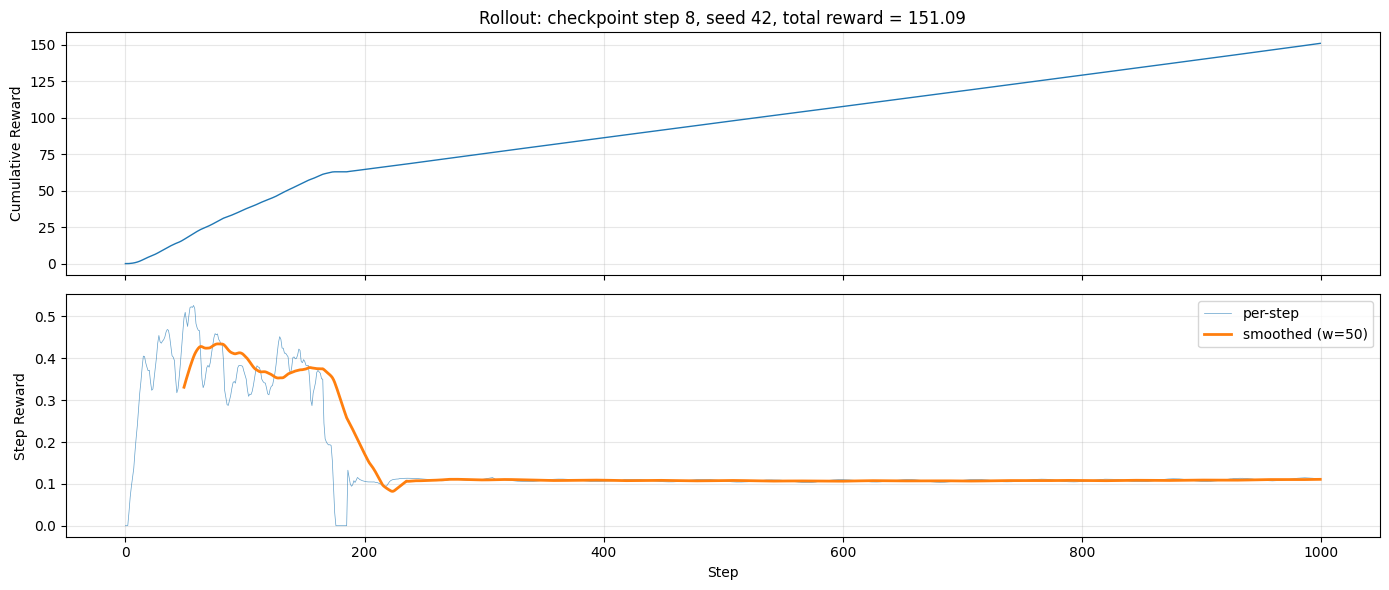

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Cumulative reward
cumulative = np.cumsum(reward_list)
axes[0].plot(cumulative, linewidth=1)
axes[0].set_ylabel("Cumulative Reward")
axes[0].set_title(
    f"Rollout: checkpoint step {latest_step}, seed {SEED}, "
    f"total reward = {total_reward:.2f}"
)
axes[0].grid(True, alpha=0.3)

# Per-step reward
axes[1].plot(reward_list, linewidth=0.5, alpha=0.7, label="per-step")
window = min(50, len(reward_list) // 5)
if window > 1:
    smoothed = np.convolve(reward_list, np.ones(window) / window, mode="valid")
    axes[1].plot(
        range(window - 1, len(reward_list)),
        smoothed,
        linewidth=2,
        label=f"smoothed (w={window})",
    )
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Step Reward")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Quick Vision Sensitivity Check

Does the agent's behavior change when vision is replaced with zeros?

In [19]:
# Test on last rollout state (which has real rendered vision)
obs_real_b = {k: jnp.array(np.array(v))[None, ...] for k, v in state.obs.items()}
obs_blank_b = {
    k: (jnp.zeros_like(v) if k == "vision" else v) for k, v in obs_real_b.items()
}

_, srng = jax.random.split(jax.random.PRNGKey(0))
act_real, _ = jit_inference_fn(params_tuple, obs_real_b, srng)
act_blank, _ = jit_inference_fn(params_tuple, obs_blank_b, srng)
sensitivity = float(jnp.linalg.norm(act_real - act_blank))

print(f"Vision sensitivity (last state): {sensitivity:.6f}")
print(f"Vision mean: {float(obs_real_b['vision'].mean()):.4f}")
print(
    f"VERDICT: {'CNN is using vision' if sensitivity > 0.01 else 'CNN is NOT using vision'}"
)

Vision sensitivity (last state): 0.071838
Vision mean: 0.1081
VERDICT: CNN is using vision


## Egocentric View Filmstrip

Sampled egocentric camera images across the rollout.

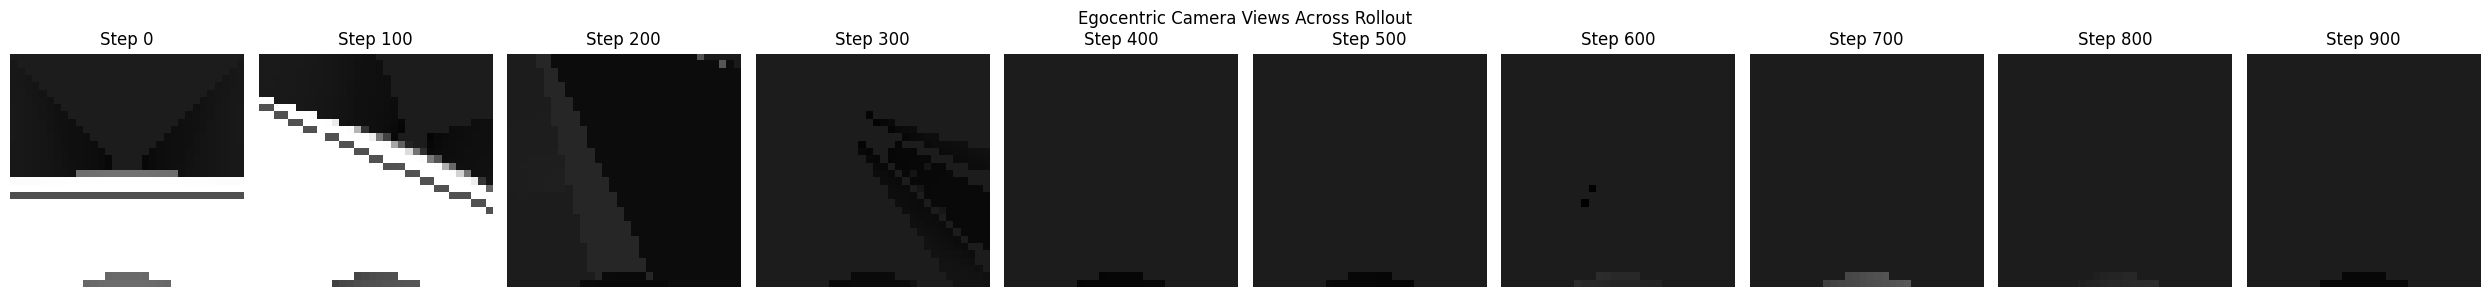

In [11]:
indices = sorted(ego_frames.keys())
n_show = min(10, len(indices))
step = max(1, len(indices) // n_show)
show_indices = indices[::step][:n_show]

fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
if n_show == 1:
    axes = [axes]
for i, idx in enumerate(show_indices):
    img = ego_frames[idx]
    axes[i].imshow(
        img[:, :, 0] if img.shape[-1] == 1 else img,
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[i].set_title(f"Step {idx}")
    axes[i].axis("off")

plt.suptitle("Egocentric Camera Views Across Rollout")
plt.tight_layout()
plt.show()